# Data Efficiency: training-set size vs. test performance

Two views over `artifacts/*/metrics.json`:

1. **Vector-based runs** (`scripts/train.py`) swept across `n_per_category` — the number of (stratified) training docs per class used to refit the final model. x-axis is already per-class.
2. **LLM few-shot runs** (`scripts/llm_classify.py`) swept across `few_shot.n_per_category`. x-axis is already per-class.

Both families now share a *samples-per-category* axis directly. Vector-based per-category samples come from the run's `n_per_category` when present, falling back to `n_train / n_classes` for legacy fraction-based runs.

In [25]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

ARTIFACTS = Path('..') / 'artifacts'
sns.set_theme(context='notebook', style='whitegrid')
pd.set_option('display.max_columns', None)

## Load runs

In [ ]:
def _load_run(metrics_path: Path) -> dict | None:
    try:
        m = json.loads(metrics_path.read_text())
    except json.JSONDecodeError:
        return None

    cfg_path = metrics_path.parent / 'config.yaml'
    cfg = {}
    if cfg_path.exists():
        try:
            cfg = yaml.safe_load(cfg_path.read_text()) or {}
        except yaml.YAMLError:
            cfg = {}

    kind = m.get('kind')
    if kind is None:
        kind = 'nested_cv' if 'nested_cv' in m else 'unknown'

    m_llm = m.get('llm') or {}
    c_llm = cfg.get('llm') or {}
    m_prompts = m.get('prompts') or {}
    c_prompts = cfg.get('prompts') or {}
    m_few = m.get('few_shot') or {}
    c_few = cfg.get('few_shot') or {}

    # n_per_category: LLM runs nest it under few_shot; vector runs (train.py)
    # write it at the top level. Coalesce across all sources, preferring metrics.
    def _coalesce(*vals):
        for v in vals:
            if v is not None:
                return v
        return None

    n_per_category = _coalesce(
        m_few.get('n_per_category'),
        c_few.get('n_per_category'),
        m.get('n_per_category'),
        cfg.get('n_per_category'),
    )

    test = m.get('test', {})
    row = {
        'run': metrics_path.parent.name,
        'kind': kind,
        'model': m.get('model') or c_llm.get('name'),
        'featurizer': m.get('featurizer'),
        'data': m.get('data') or (cfg.get('data') or {}).get('name'),
        'n_train': m.get('n_train'),
        'n_test': m.get('n_test'),
        'n_classes': m.get('n_classes'),
        'train_fraction': m.get('train_fraction'),  # legacy fraction-based runs
        'test_accuracy': test.get('accuracy'),
        'test_f1_macro': test.get('f1_macro'),
        'test_f1_weighted': test.get('f1_weighted'),
        'n_per_category': n_per_category,
        'summary_fraction': m_llm.get('fraction', cfg.get('fraction')),
        'llm_tag': m_llm.get('tag', c_llm.get('tag')),
        'prompts': m_prompts.get('name', c_prompts.get('name')),
    }
    return row


# Vector/Qwen runs live one level under artifacts/; Claude's append-only store
# nests under artifacts/_claude_eval/<run>/, so glob both.
metrics_paths = sorted(ARTIFACTS.glob('*/metrics.json')) + \
                sorted(ARTIFACTS.glob('_claude_eval/*/metrics.json'))
rows = [r for p in metrics_paths if (r := _load_run(p))]
runs = pd.DataFrame(rows)
print(f'Loaded {len(runs)} runs')
runs.head()

## Derive samples-per-category

- Vector-based (`kind == 'nested_cv'`): `n_per_category` when present, else `n_train / n_classes` (legacy fraction-based runs).
- LLM few-shot: `n_per_category` directly. Zero-shot runs (`n_per_category == 0`) are kept but not plotted on the log axis.

In [ ]:
is_vec = runs['kind'].isin(['nested_cv', 'vector_cv'])
is_llm = runs['kind'].isin(['llm_few_shot', 'llm_zero_shot'])

runs['samples_per_category'] = np.nan
# Vector: prefer the explicit n_per_category; fall back to n_train / n_classes
# for legacy fraction-based runs (and for full-data runs where it is null).
vec_npc = runs.loc[is_vec, 'n_per_category'].astype(float)
vec_fallback = (
    runs.loc[is_vec, 'n_train'].astype(float) / runs.loc[is_vec, 'n_classes'].astype(float)
)
runs.loc[is_vec, 'samples_per_category'] = vec_npc.fillna(vec_fallback)
runs.loc[is_llm, 'samples_per_category'] = runs.loc[is_llm, 'n_per_category'].astype(float)

runs['family'] = np.where(is_vec, 'vector', np.where(is_llm, 'llm', 'other'))
runs['variant'] = np.where(
    is_vec,
    runs['model'].astype(str) + '+' + runs['featurizer'].astype(str),
    runs['model'].astype(str) + '|' + runs['prompts'].fillna('').astype(str),
)
runs[['run', 'family', 'variant', 'samples_per_category', 'test_f1_macro']].head()

## Leaderboard — vector-based across `n_per_category`

In [ ]:
vec = runs[is_vec].copy()
vec_board = (
    vec.assign(samples_per_category=vec['samples_per_category'].round(1))
       .sort_values(['variant', 'samples_per_category'])
       [[
           'variant', 'model', 'featurizer', 'n_per_category', 'n_train',
           'samples_per_category', 'test_f1_macro', 'test_accuracy',
           'test_f1_weighted', 'run',
       ]]
       .reset_index(drop=True)
)
vec_board.style.background_gradient(
    subset=['test_f1_macro', 'test_accuracy', 'test_f1_weighted'], cmap='Greens'
).format({
    'samples_per_category': '{:.1f}',
    'test_f1_macro': '{:.4f}',
    'test_accuracy': '{:.4f}',
    'test_f1_weighted': '{:.4f}',
})

In [ ]:
# Per-variant scatter — vector-based
if not vec.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(
        data=vec, x='samples_per_category', y='test_accuracy', hue='variant',
        style='variant', s=110, ax=ax,
    )
    sns.lineplot(
        data=vec.sort_values('samples_per_category'),
        x='samples_per_category', y='test_accuracy', hue='variant',
        legend=False, ax=ax, alpha=0.4,
    )
    ax.set_xscale('log')
    ax.set_xlabel('training samples per category (log)')
    ax.set_ylabel('test_accuracy')
    ax.set_title('Vector-based: test accuracy vs. samples per category')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

> **Caveat — Claude runs use a smaller test set.** Claude runs (`model == claude_sonnet`, from `artifacts/_claude_eval/`) are scored on a balanced subset of `test_per_category × n_classes` documents, whereas the Qwen and vector-based runs use the full ~3770-doc held-out test set. Claude `n_test` and `test_accuracy` are therefore *indicative* and not measured on the identical test set — treat cross-family comparisons accordingly.

## Leaderboard — LLM few-shot across `n_per_category`

In [30]:
llm = runs[is_llm].copy()
llm_board = (
    llm.sort_values(['model', 'n_per_category'])
       [[
           'model', 'llm_tag', 'prompts', 'n_per_category', 'summary_fraction',
           'test_f1_macro', 'test_accuracy', 'test_f1_weighted', 'n_test', 'run',
       ]]
       .reset_index(drop=True)
)
llm_board.style.background_gradient(
    subset=['test_f1_macro', 'test_accuracy', 'test_f1_weighted'], cmap='Purples'
).format({
    'summary_fraction': '{:.2f}',
    'test_f1_macro': '{:.4f}',
    'test_accuracy': '{:.4f}',
    'test_f1_weighted': '{:.4f}',
})

,model,llm_tag,prompts,n_per_category,summary_fraction,test_f1_macro,test_accuracy,test_f1_weighted,n_test,run
0,claude_sonnet,claude-sonnet-4-6,zero_shot_v1,0.000000,0.25,0.7246,0.7164,0.7245,2000,claude_sonnet_zero_shot_v1_n0_summary0.25_20ng
1,claude_sonnet,claude-sonnet-4-6,few_shot_v1,1.000000,0.25,0.7344,0.7299,0.7343,2000,claude_sonnet_few_shot_v1_n1_summary0.25_20ng
2,qwen25_7b,qwen2.5:7b-instruct,zero_shot_v1,0.000000,0.10,0.4508,0.4679,0.4608,3770,qwen25_7b_zero_shot_v1_n0_summary0.1_20ng
3,qwen25_7b,qwen2.5:7b-instruct,zero_shot_v1,0.000000,0.25,0.4650,0.4767,0.4749,3770,qwen25_7b_zero_shot_v1_n0_summary0.25_20ng
4,qwen25_7b,qwen2.5:7b-instruct,zero_shot_v1,0.000000,0.50,0.4608,0.4775,0.4712,3770,qwen25_7b_zero_shot_v1_n0_summary0.5_20ng
5,qwen25_7b,qwen2.5:7b-instruct,zero_shot_v1,0.000000,0.75,0.4737,0.4902,0.4835,3770,qwen25_7b_zero_shot_v1_n0_summary0.75_20ng
6,qwen25_7b,qwen2.5:7b-instruct,zero_shot_v1,0.000000,1.00,0.4769,0.4966,0.4870,3770,qwen25_7b_zero_shot_v1_n0_summary1.0_20ng
7,qwen25_7b,qwen2.5:7b-instruct,few_shot_v1,1.000000,0.10,0.5085,0.5127,0.5182,3770,qwen25_7b_few_shot_v1_n1_summary0.1_20ng
8,qwen25_7b,qwen2.5:7b-instruct,few_shot_v1,1.000000,0.25,0.5024,0.5074,0.5113,3770,qwen25_7b_few_shot_v1_n1_summary0.25_20ng
9,qwen25_7b,qwen2.5:7b-instruct,few_shot_v1,1.000000,0.50,0.5230,0.5220,0.5333,3770,qwen25_7b_few_shot_v1_n1_summary0.5_20ng


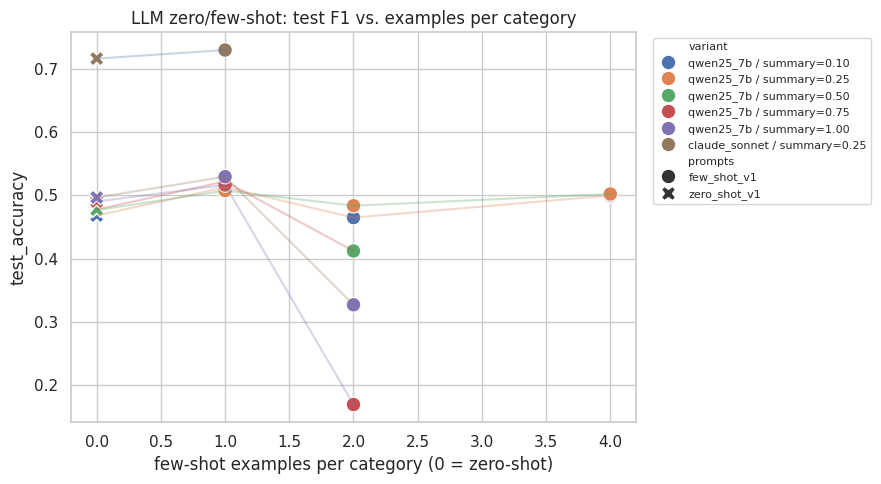

In [31]:
# Per-(model, summary_fraction) scatter — LLM zero/few-shot
if not llm.empty:
    llm_plot = llm.copy()
    llm_plot['variant'] = (
        llm_plot['model'].astype(str)
        + ' / summary='
        + llm_plot['summary_fraction'].map(lambda x: f'{x:.2f}' if pd.notna(x) else 'NA')
    )
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.scatterplot(
        data=llm_plot, x='n_per_category', y='test_accuracy',
        hue='variant', style='prompts', s=110, ax=ax,
    )
    for _, sub in llm_plot.groupby('variant'):
        sub = sub.sort_values('n_per_category')
        if len(sub) > 1:
            ax.plot(sub['n_per_category'], sub['test_accuracy'], alpha=0.3)
    ax.set_xlabel('few-shot examples per category (0 = zero-shot)')
    ax.set_ylabel('test_accuracy')
    ax.set_title('LLM zero/few-shot: test F1 vs. examples per category')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

## Combined: test F1 vs. training samples per category

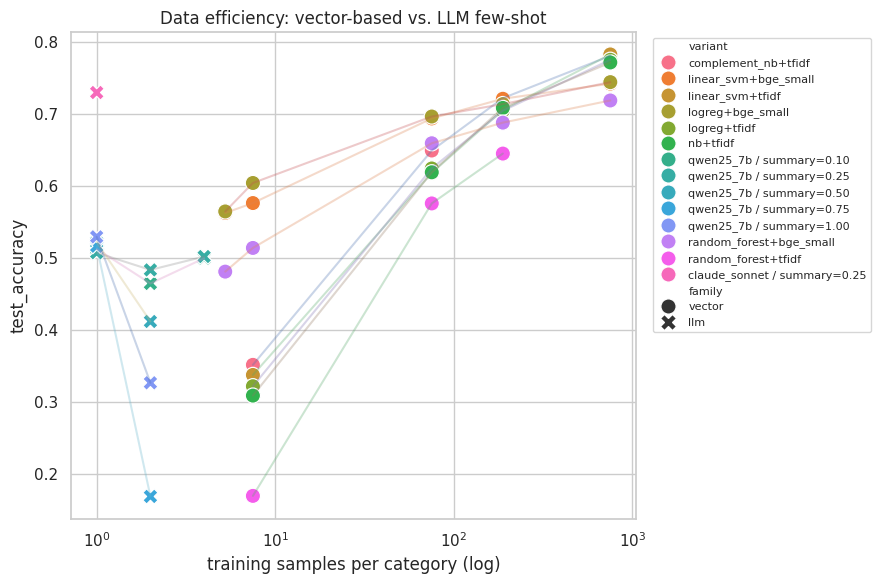

In [32]:
combo = runs[runs['samples_per_category'].notna() & runs['test_f1_macro'].notna()].copy()
combo = combo[combo['samples_per_category'] > 0]

# Re-derive variant so LLM runs are grouped by (model, summary_fraction)
combo['variant'] = np.where(
    combo['family'] == 'vector',
    combo['model'].astype(str) + '+' + combo['featurizer'].astype(str),
    combo['model'].astype(str)
        + ' / summary='
        + combo['summary_fraction'].map(lambda x: f'{x:.2f}' if pd.notna(x) else 'NA'),
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=combo, x='samples_per_category', y='test_accuracy',
    hue='variant', style='family', s=120, ax=ax,
)
for variant, sub in combo.groupby('variant'):
    sub = sub.sort_values('samples_per_category')
    if len(sub) > 1:
        ax.plot(sub['samples_per_category'], sub['test_accuracy'], alpha=0.3)
ax.set_xscale('log')
ax.set_xlabel('training samples per category (log)')
ax.set_ylabel('test_accuracy')
ax.set_title('Data efficiency: vector-based vs. LLM few-shot')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()